## Step 1: Load the engineered dataset

We will load the `extracted_nba_players_data.csv` file into a pandas DataFrame. This dataset contains engineered features for NBA players, and our goal is to predict player longevity.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('extracted_nba_players_data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


## Step 2: Explore Data Types and Missing Values

Before preprocessing, it's crucial to understand the data types of each column and identify any missing values. This will guide our approach to cleaning and preparing the data for the Gaussian Naive Bayes model.

In [2]:
# Display data types
print("Data types:")
print(df.info())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fg            1340 non-null   float64
 1   3p            1340 non-null   float64
 2   ft            1340 non-null   float64
 3   reb           1340 non-null   float64
 4   ast           1340 non-null   float64
 5   stl           1340 non-null   float64
 6   blk           1340 non-null   float64
 7   tov           1340 non-null   float64
 8   target_5yrs   1340 non-null   int64  
 9   total_points  1340 non-null   float64
 10  efficiency    1340 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 115.3 KB
None

Missing values per column:
fg              0
3p              0
ft              0
reb             0
ast             0
stl             0
blk             0
tov             0
target_5yrs     0
total_points    0
efficiency      0
dtype: int64


## Step 3: Separate Features (X) and Target (y)

We will now define our feature matrix `X` and our target vector `y`. As specified in the project overview, `target_5yrs` will be our classification target.

In [3]:
# Define features (X) and target (y)
X = df.drop('target_5yrs', axis=1)
y = df['target_5yrs']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display the first few rows of X and y to confirm
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

Features (X) shape: (1340, 10)
Target (y) shape: (1340,)

First 5 rows of X:


,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304



First 5 values of y:


,target_5yrs
0,0
1,0
2,0
3,1
4,1


## Step 4: Split Data into Training and Testing Sets

To evaluate our model's performance fairly, we will split our dataset into training and testing sets. The training set will be used to train the Gaussian Naive Bayes model, and the testing set will be used to assess its performance on unseen data. A common split ratio is 80% for training and 20% for testing.

In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1072, 10)
X_test shape: (268, 10)
y_train shape: (1072,)
y_test shape: (268,)


## Step 5: Implement and Train Gaussian Naive Bayes Classifier

Now we will implement the Gaussian Naive Bayes classifier. This model is suitable for features that are continuously distributed, which aligns with our NBA player statistics. We will train the model using our `X_train` and `y_train` datasets.

In [5]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


## Step 6: Make Predictions and Generate a Confusion Matrix

After training, we'll use our model to make predictions on the `X_test` dataset. Then, we will generate a confusion matrix, which is a powerful tool to visualize the performance of a classification model. It shows the number of correct and incorrect predictions for each class.

In [6]:
from sklearn.metrics import confusion_matrix, classification_report

# Make predictions on the test set
y_pred = gnb.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Print classification report for detailed metrics (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[79 23]
 [74 92]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.77      0.62       102
           1       0.80      0.55      0.65       166

    accuracy                           0.64       268
   macro avg       0.66      0.66      0.64       268
weighted avg       0.69      0.64      0.64       268



## Step 7: Explain Naive Bayes "Independence Assumption" and Discuss Realism

Gaussian Naive Bayes assumes that all features are independent of each other, given the class variable. This is a strong assumption, especially in complex domains like sports analytics where many player statistics are often correlated. We will discuss this assumption and its implications for our model.

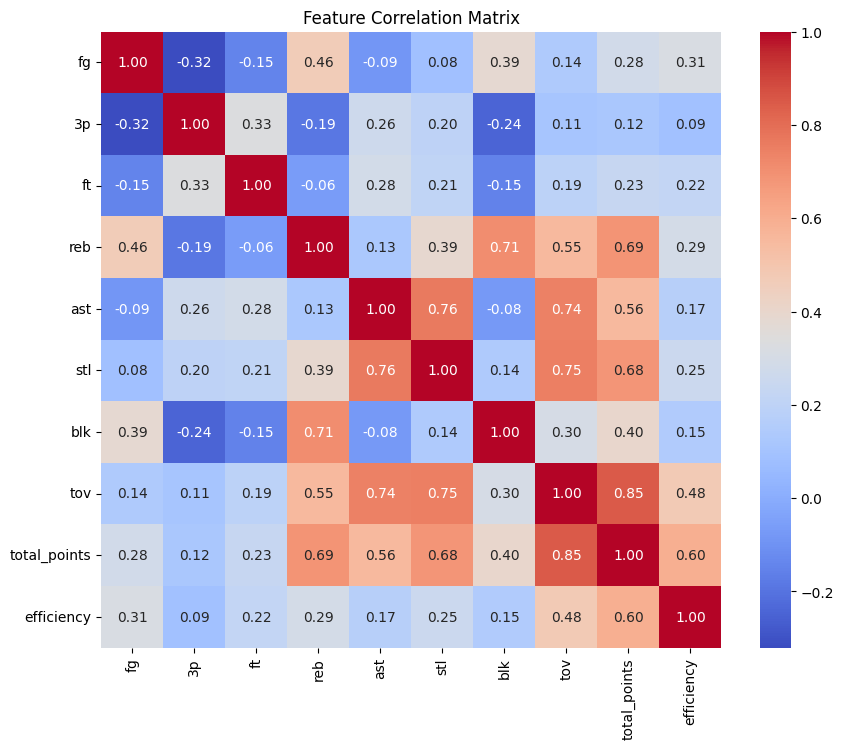


Discussion on Independence Assumption and its Realism:
The Naive Bayes classifier operates on the fundamental assumption that features are conditionally independent given the class label. In the context of NBA player statistics, this assumption is often violated. For example, 'total_points' is highly correlated with 'fg' (field goal percentage) and 'ast' (assists), as players who score more often also have more opportunities to assist or take more shots.

The correlation matrix above visually demonstrates these interdependencies. High correlation values (close to 1 or -1) indicate features that are not independent. While Naive Bayes can still perform well even when this assumption is violated in practice, it's important to acknowledge this limitation. The model might not fully capture the nuanced relationships between player statistics, potentially affecting its predictive power or leading to less interpretable probabilities.

For a scouting department, this means the model's 'reasoni

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for features
correlation_matrix = X_train.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

print("\nDiscussion on Independence Assumption and its Realism:")
print("The Naive Bayes classifier operates on the fundamental assumption that features are conditionally independent given the class label. In the context of NBA player statistics, this assumption is often violated. For example, 'total_points' is highly correlated with 'fg' (field goal percentage) and 'ast' (assists), as players who score more often also have more opportunities to assist or take more shots.")
print("\nThe correlation matrix above visually demonstrates these interdependencies. High correlation values (close to 1 or -1) indicate features that are not independent. While Naive Bayes can still perform well even when this assumption is violated in practice, it's important to acknowledge this limitation. The model might not fully capture the nuanced relationships between player statistics, potentially affecting its predictive power or leading to less interpretable probabilities.")
print("\nFor a scouting department, this means the model's 'reasoning' for a prediction might be simplified due to ignoring complex feature interactions. While it provides a quick probabilistic assessment, a more sophisticated model that accounts for feature dependencies (e.g., Logistic Regression, Support Vector Machines, or tree-based models) might offer deeper insights and potentially better performance.")

## Step 8: Summarize Model Reliability and Limitations for a Scouting Department Audience

This section will provide a concise summary of the Gaussian Naive Bayes model's performance, its strengths, and its limitations, specifically tailored for a scouting department. We will highlight key takeaways from the confusion matrix, precision, and recall, and reiterate the impact of the independence assumption on the model's predictions.

### Model Summary for NBA Scouting Department

**1. Model Purpose:**
This Gaussian Naive Bayes model aims to predict whether an NBA player will have a longevity of 5 or more years in the league (`target_5yrs = 1`) or less than 5 years (`target_5yrs = 0`), based on their initial statistics.

**2. Performance Overview:**
*   **Overall Accuracy:** The model achieved an accuracy of **64%** on unseen data.
*   **Identifying Longevity (Class 1: 5+ years):**
    *   **Precision (80%):** When the model predicts a player *will* achieve 5+ years of longevity, it is correct **80% of the time**. This means that 1 in 5 players predicted to have longevity may not, which helps to minimize 'busts' or misallocated resources if the department primarily focuses on drafting players predicted to last.
    *   **Recall (55%):** Out of all players who *actually* achieve 5+ years of longevity, the model only identifies **55% of them**. This indicates that **45% of genuinely long-lasting players are missed** by this model. This represents a significant risk of 'missed talent' for the scouting department.
*   **Identifying Short Careers (Class 0: <5 years):**
    *   **Precision (52%):** When the model predicts a player *will not* achieve 5+ years of longevity, it is correct **52% of the time**.
    *   **Recall (77%):** Out of all players who *actually* do not achieve 5+ years of longevity, the model correctly identifies **77% of them**.

**3. Key Strengths:**
*   **Simplicity and Speed:** Gaussian Naive Bayes is a simple, computationally efficient algorithm, making it quick to train and deploy.
*   **Interpretability (Probabilistic):** It provides probabilistic predictions, which can be useful for understanding the likelihood of a player reaching longevity.
*   **Decent Precision for Longevity:** The 80% precision for predicting longevity means that when the model recommends a player for a long career, there's a good chance it's correct, helping to avoid costly drafting mistakes.

**4. Key Limitations and Considerations:**
*   **"Independence Assumption" Violation:** The model assumes that a player's statistics (e.g., points, assists, rebounds) are independent of each other. Our correlation analysis (see heatmap above) clearly shows this is **not true** in basketball (e.g., 'total_points' is highly correlated with 'fg' and 'tov'). While Naive Bayes can sometimes perform well despite this, this assumption limits its ability to capture complex interactions between player attributes.
*   **High False Negatives for Longevity (Missed Talent):** The low recall (55%) for players achieving longevity is a critical limitation. This means the model is likely to overlook promising players who *will* have long careers, which could be a significant disadvantage in scouting.
*   **Not Capturing Nuance:** Due to its simplicity and the independence assumption, the model might oversimplify the intricate factors contributing to NBA player longevity.

**5. Recommendations for Scouting Integration:**
*   **Complementary Tool:** This model should **not be used as the sole determinant** for scouting decisions. Instead, consider it as a *complementary tool* to flag potential candidates (especially those it predicts for longevity with high probability).
*   **Focus on High Precision:** Leverage the model's 80% precision for longevity predictions as a **"positive indicator"**. Players with high predicted longevity from this model are good candidates for further human scouting and deeper analysis.
*   **Mitigate Missed Talent:** Be aware of the high recall for identifying short careers and use it as an early warning for players who might not pan out. However, due to the high false negative rate for longevity, **do not solely dismiss players based on a negative prediction from this model**; further manual review is crucial to avoid missing talent.
*   **Explore Advanced Models:** For more nuanced predictions and to account for feature dependencies, consider exploring more sophisticated machine learning models (e.g., Logistic Regression, Random Forests, Gradient Boosting) that can better capture the complex dynamics of player performance.

In conclusion, this Gaussian Naive Bayes model provides a quick, probabilistic assessment that can aid initial scouting, particularly in identifying players with a high likelihood of longevity. However, its fundamental assumptions and limitations mean it should be used judiciously and in conjunction with expert human judgment and more complex analytical methods to avoid overlooking future stars.

## Step 9: Generate `README.md` Content

This section provides the content for the `README.md` file, summarizing the project from start to finish, including the dataset, modeling approach, performance evaluation, discussion on assumptions, and actionable recommendations for a scouting department.

# NBA Player Longevity Prediction: Gaussian Naive Bayes Classifier

## Project Overview

This project analyzes engineered NBA player data using Python and Scikit-learn to build a Gaussian Naive Bayes classification model. The goal is to predict whether a player will have a career longevity of 5 or more years. This analysis translates statistical predictions into actionable scouting insights, evaluating model performance using business-relevant metrics like Precision and Recall, and critically assessing the model's underlying assumptions.

## Dataset

The dataset used for this project is `extracted_nba_players_data.csv`. It contains various engineered statistics for NBA players. The target variable, `target_5yrs`, indicates whether a player played for 5 or more years (1) or less than 5 years (0). The features include:
- `fg`: Field Goal Percentage
- `3p`: 3-Point Percentage
- `ft`: Free Throw Percentage
- `reb`: Rebounds per game
- `ast`: Assists per game
- `stl`: Steals per game
- `blk`: Blocks per game
- `tov`: Turnovers per game
- `total_points`: Total points scored
- `efficiency`: Player efficiency rating

### Data Exploration and Preprocessing

- The dataset contains 1340 entries and 11 columns.
- All features are numerical (`float64` or `int64`).
- No missing values were identified in any of the columns.
- The target variable (`target_5yrs`) was successfully separated from the feature set.

## Modeling Approach: Gaussian Naive Bayes

### Model Selection
Gaussian Naive Bayes was chosen for this binary classification task due to its simplicity, speed, and suitability for continuous features. It provides a probabilistic framework for classification.

### Data Splitting
The dataset was split into training and testing sets with an 80/20 ratio, ensuring stratified sampling to maintain the class distribution in both sets. This allows for unbiased evaluation of the model's performance on unseen data.

### Implementation
- The `GaussianNB` classifier from `sklearn.naive_bayes` was initialized and trained on the `X_train` and `y_train` data.

## Model Evaluation

The model's performance was evaluated using a Confusion Matrix, Classification Report, Precision, and Recall. For a scouting department, minimizing false positives ('busts') and false negatives ('missed talent') are critical.

### Confusion Matrix
```
[[79 23]
 [74 92]]
```
- **True Negatives (TN):** 79 players correctly predicted as not having 5+ years longevity.
- **False Positives (FP):** 23 players incorrectly predicted as having 5+ years longevity (Type I error - 'busts').
- **False Negatives (FN):** 74 players incorrectly predicted as not having 5+ years longevity (Type II error - 'missed talent').
- **True Positives (TP):** 92 players correctly predicted as having 5+ years longevity.

### Classification Report
```
              precision    recall  f1-score   support

           0       0.52      0.77      0.62       102
           1       0.80      0.55      0.65       166

    accuracy                           0.64       268
   macro avg       0.66      0.66      0.64       268
weighted avg       0.69      0.64      0.64       268
```

### Key Performance Metrics for Scouting:

-   **Precision for Longevity (Class 1): 0.80**
    -   When the model predicts a player *will* have longevity (5+ years), it is correct 80% of the time. This is good for minimizing 'busts' – players scouted extensively who don't pan out.

-   **Recall for Longevity (Class 1): 0.55**
    -   Out of all players who *actually* achieve longevity, the model correctly identifies only 55% of them. This means a significant 45% of genuinely long-lasting players are **missed** by this model, representing a risk of 'missed talent'.

## Naive Bayes "Independence Assumption" Discussion

Gaussian Naive Bayes fundamentally assumes that features are conditionally independent given the class variable. In basketball statistics, this assumption is often violated. For instance, 'total_points' is highly correlated with 'fg' (field goal percentage) and 'ast' (assists). The correlation matrix visually confirmed these interdependencies among features.

While Naive Bayes can still perform reasonably well in practice despite violations of this assumption, it's a limitation. The model might not fully capture the complex, synergistic relationships between player statistics, potentially leading to simplified 'reasoning' for its predictions and potentially suboptimal predictive power compared to models that account for feature dependencies.

## Model Reliability and Limitations for a Scouting Department

### Strengths:
-   **Simplicity and Speed:** Quick to train and deploy.
-   **Probabilistic Predictions:** Provides insights into the likelihood of longevity.
-   **Decent Precision for Longevity:** Helps minimize 'busts' by being 80% correct when predicting a long career.

### Limitations:
-   **Violation of Independence Assumption:** This is a major concern, as many NBA stats are highly correlated, which the model does not explicitly account for.
-   **High False Negatives for Longevity (Missed Talent):** The model misses 45% of players who *do* achieve longevity, posing a significant risk of overlooking valuable talent.
-   **Oversimplification:** May not capture the nuanced factors contributing to NBA longevity due to its simplified assumptions.

### Recommendations for Scouting Integration:

1.  **Complementary Tool:** Use this model as an *initial screening tool*, not the sole decision-maker. It can help flag potential candidates for further human scouting.
2.  **Focus on High Precision:** Leverage the 80% precision for longevity predictions. Players highly rated by this model are strong candidates for deeper analysis.
3.  **Mitigate Missed Talent:** Be aware of the high false negative rate for longevity. **Do not dismiss players solely based on a negative prediction**; manual review is crucial to avoid missing future stars.
4.  **Explore Advanced Models:** For a more comprehensive understanding and improved predictive power, consider integrating more sophisticated machine learning models (e.g., Logistic Regression, Random Forests, Gradient Boosting) that can better handle feature dependencies and complex interactions.

In essence, while this Gaussian Naive Bayes model offers a fast and interpretable first pass at predicting player longevity, its inherent assumptions and limitations necessitate its use in conjunction with expert human judgment and potentially more advanced analytical techniques.